In [5]:
from aicsimageio import AICSImage
from aicsimageio.readers import BioformatsReader
import dask.array as da
import matplotlib.pyplot as plt


In [2]:
img = AICSImage(
    "/Volumes/STICK/245/245_003.vsi",
    reader=BioformatsReader,          # <- force Bio-Formats
    reconstruct_mosaic=False
)

print(img.dims)                       # e.g. TCZYX
data = img.get_image_dask_data("TCZYX")
print(data.shape)

# Example: get one 2D slice as NumPy
import dask.array as da

t, c = 0, 0
z_mid = data.shape[2] // 2
slice_np = data[t, c, z_mid].compute()

SLF4J: No SLF4J providers were found.
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See https://www.slf4j.org/codes.html#noProviders for further details.


<Dimensions [T: 1, C: 1, Z: 1, Y: 4385, X: 27540]>
(1, 1, 1, 4385, 27540)


In [ ]:
# take the only T, C, Z index
img2d = data[0, 0, 0]      # shape (Y, X) as dask array
img2d = img2d.compute()    # convert to NumPy
print(img2d.shape, img2d.dtype)

(4385, 27540) uint8


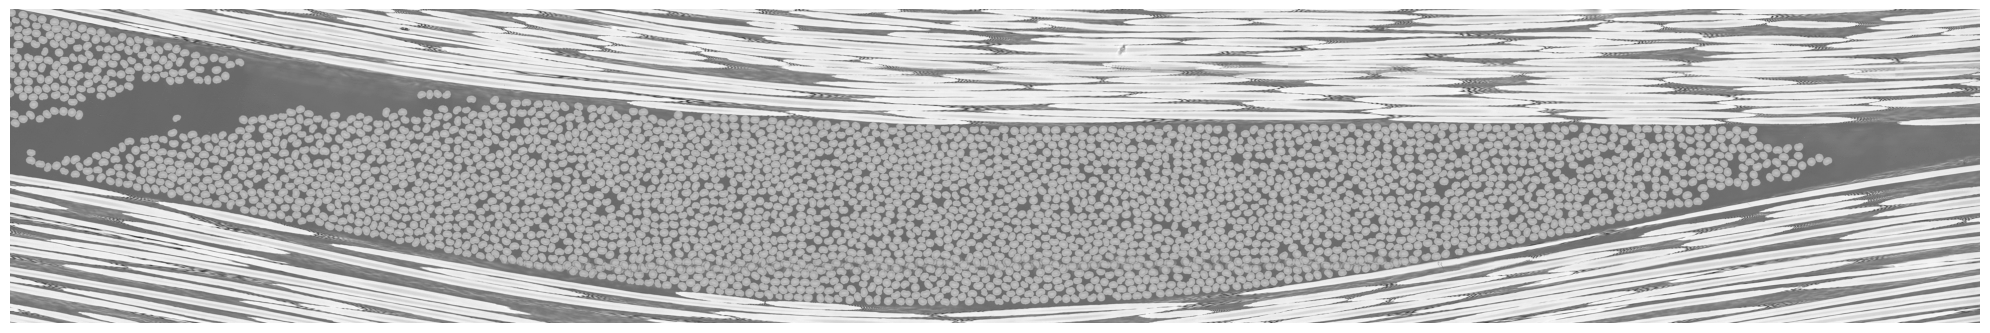

In [7]:

plt.figure(figsize=(20, 4))
plt.imshow(img2d, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()